# Speech Emotion Recognition — V3 (simplified)
**Foundation Project P4 · Group 07** — one notebook, top to bottom: **data → EDA → features → model comparison → one test evaluation → explainability → model registry**.

**Problem.** Recognise the emotion in a short speech clip (8 classes) *from speakers the model has never heard*, so a contact centre can (a) escalate distressed callers and (b) auto-tag confident clips so analysts only review the uncertain ones.

**What changed vs. earlier versions**

| | Approach | Test accuracy (same 5 unseen speakers) |
|---|---|---|
| V1 (mid review) | 394 hand-crafted librosa features + tree/MLP ensembles + CNN-BiLSTM blend | 59.7 % |
| V2 (final review) | 6 frozen pre-trained encoders (~9 GB) + probe fusion; v2 adds EM speaker adaptation that needs ≥5 clips of the same caller | 73.3 % (single clip) |
| **V3 (this notebook)** | **2 frozen encoders (WavLM-Large + Whisper-Medium) + one logistic regression each, probabilities averaged** | **78.3 %** (section 5) |

V3 keeps the part of V2 that carried the accuracy — **transfer learning with frozen pre-trained speech encoders** (as suggested by the TA) — and drops what did not: four of the six encoders, stacking, fine-tuning and caller-level adaptation (which cannot work on a single voice memo). The result is small enough to ship as one Docker image with an API and a web UI (`api/`, `Dockerfile`).

**Run time** on an Apple M-series laptop: ≈ 15 min the first time (downloads ~4.5 GB of encoders and embeds every clip twice), ≈ 2 min afterwards (embeddings are cached in `artifacts/cache`).

## 0 · Setup

In [1]:
import hashlib, json, sys, time, warnings
from pathlib import Path

import librosa, librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd()))
from ser import EmotionModel, config as C
from ser.audio import add_noise, load_file
from ser.encoders import device, embed_layers
from ser.model import make_probe

warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(C.SEED)
for d in (C.FIG_DIR, C.CACHE_DIR, C.ARTIFACTS / "results"):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
EMO_COLORS = dict(zip(C.EMOTIONS, sns.color_palette("tab10", 8)))

def savefig(name):
    plt.tight_layout()
    plt.savefig(C.FIG_DIR / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

def scores(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred), "uar": balanced_accuracy_score(y_true, y_pred),
            "macro_f1": f1_score(y_true, y_pred, average="macro")}

print("compute device:", device())

ModuleNotFoundError: No module named 'librosa'

## 1 · Data understanding and audit
**RAVDESS speech subset** (Livingstone & Russo, 2018; CC BY-NC-SA 4.0): 24 professional actors (12 female, 12 male), two fixed sentences, 8 emotions. Everything we need is encoded in the file name `emotion-intensity-statement-repetition-actor.wav`.
Only **emotion** is the target. Intensity, statement, repetition and gender are kept for analysis only — a real caller's audio would not come with them, so using them as inputs would be leakage.

In [ ]:
DATA = C.find_data_dir()
rows = []
for wav in sorted(DATA.glob("Person*/*.wav")):
    parts = wav.stem.split("-")
    if wav.name.startswith("._") or len(parts) != 5:
        continue                                           # macOS resource-fork copies etc.
    emo, intensity, statement, rep, actor = map(int, parts)
    rows.append({"path": str(wav), "speaker": f"Person{actor:02d}", "gender": "male" if actor % 2 else "female",
                 "emotion": C.EMOTIONS[emo - 1], "label": emo - 1,
                 "intensity": "strong" if intensity == 2 else "normal", "statement": statement, "repetition": rep})
meta = pd.DataFrame(rows)

def audit(path):
    info = sf.info(path)
    y, sr = sf.read(path, dtype="float32")
    y = y.mean(axis=1) if y.ndim > 1 else y
    _, (s, e) = librosa.effects.trim(y, top_db=30)
    return {"sample_rate": info.samplerate, "channels": info.channels, "duration_s": info.duration,
            "speech_s": (e - s) / sr, "peak": float(np.abs(y).max()),
            "md5": hashlib.md5(Path(path).read_bytes()).hexdigest()}

meta = meta.join(pd.DataFrame([audit(p) for p in tqdm(meta.path, desc="audit")]))
print(f"{len(meta)} clips · {meta.speaker.nunique()} speakers · {meta.emotion.nunique()} emotions")
print("sample rates:", meta.sample_rate.value_counts().to_dict(), "· channels:", meta.channels.value_counts().to_dict())
print("clipped files (peak ≥ 0.999):", int((meta.peak >= 0.999).sum()))
dups = meta[meta.md5.duplicated(keep=False)]
print("byte-identical duplicates:", [str(Path(p).relative_to(DATA)) for p in dups.path] or "none")

audit:   0%|          | 0/1440 [00:00<?, ?it/s]

1440 clips · 24 speakers · 8 emotions
sample rates: {48000: 1440} · channels: {1: 1435, 2: 5}
clipped files (peak ≥ 0.999): 1
byte-identical duplicates: ['Person07/03-01-02-01-07.wav', 'Person07/03-01-02-02-07.wav']


In [ ]:
# Cleaning: drop exact duplicates (keep the first copy); split speakers exactly as in V1/V2
meta = meta[~meta.md5.duplicated()].reset_index(drop=True)
meta["split"] = np.where(meta.speaker.isin(C.TEST_SPEAKERS), "test", "dev")
dev, test = meta.split.eq("dev").to_numpy(), meta.split.eq("test").to_numpy()
y = meta.label.to_numpy()
print(f"development: {dev.sum()} clips from {meta[dev].speaker.nunique()} speakers | "
      f"test: {test.sum()} clips from {meta[test].speaker.nunique()} speakers {C.TEST_SPEAKERS}")
meta.drop(columns=["path"]).describe(include="all").T.head(12)

development: 1139 clips from 19 speakers | test: 300 clips from 5 speakers ['Person01', 'Person09', 'Person12', 'Person17', 'Person19']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
speaker,1439,24,Person01,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1439,2,female,720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
emotion,1439,8,calm,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,1439.0,NaN,NaN,NaN,3.734538,2.175632,0.0,2.0,4.0,6.0,7.0
intensity,1439,2,normal,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
statement,1439.0,NaN,NaN,NaN,1.499653,0.500174,1.0,1.0,1.0,2.0,2.0
repetition,1439.0,NaN,NaN,NaN,1.499653,0.500174,1.0,1.0,1.0,2.0,2.0
sample_rate,1439.0,NaN,NaN,NaN,48000.0,0.0,48000.0,48000.0,48000.0,48000.0,48000.0
channels,1439.0,NaN,NaN,NaN,1.003475,0.058864,1.0,1.0,1.0,1.0,2.0
duration_s,1439.0,NaN,NaN,NaN,3.700871,0.336701,2.936271,3.470146,3.670333,3.870542,5.271937


## 2 · Exploratory data analysis
Four questions drive the EDA:
1. Are the classes balanced? → decides the metric.
2. How much of each clip is actually speech? → decides pre-processing.
3. Do simple acoustic cues (pitch, loudness) separate emotions — and what else do they depend on? → decides the feature strategy.
4. What does emotion look like in the signal? → intuition for the model.

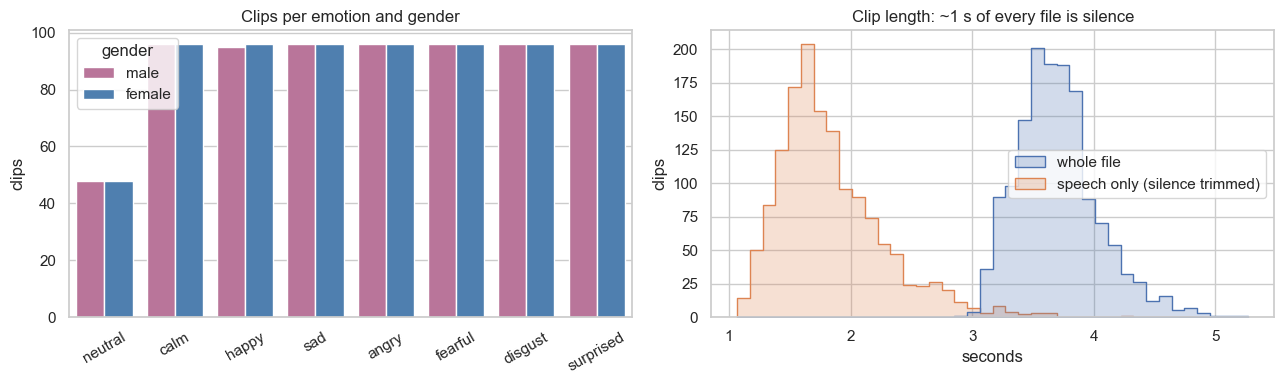

{'neutral': 96, 'calm': 192, 'happy': 191, 'sad': 192, 'angry': 192, 'fearful': 192, 'disgust': 192, 'surprised': 192}
median file 3.67 s, median speech 1.74 s


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
order = C.EMOTIONS
sns.countplot(data=meta, x="emotion", hue="gender", order=order, ax=ax[0], palette=["#c46a9b", "#3f7fbf"])
ax[0].set(title="Clips per emotion and gender", xlabel="", ylabel="clips"); ax[0].tick_params(axis="x", rotation=30)
m = meta.melt(value_vars=["duration_s", "speech_s"], var_name="", value_name="seconds")
m[""] = m[""].map({"duration_s": "whole file", "speech_s": "speech only (silence trimmed)"})
sns.histplot(data=m, x="seconds", hue="", bins=40, ax=ax[1], element="step")
ax[1].set(title="Clip length: ~1 s of every file is silence", xlabel="seconds", ylabel="clips")
savefig("eda_balance_and_duration")
print(meta.emotion.value_counts().reindex(order).to_dict())
print(f"median file {meta.duration_s.median():.2f} s, median speech {meta.speech_s.median():.2f} s")

**Findings.** (1) Seven emotions have 192 clips; *neutral* has 96 (it has no "strong" intensity) and every emotion is split evenly by gender. The imbalance is mild, so we report **accuracy** and also **macro-F1 / UAR** so neutral is not ignored.
(2) About a third of each file is leading/trailing silence → we **trim silence** (same function at training and in the API), otherwise the model learns from silence length.

decode 16 kHz + trim:   0%|          | 0/1439 [00:00<?, ?it/s]

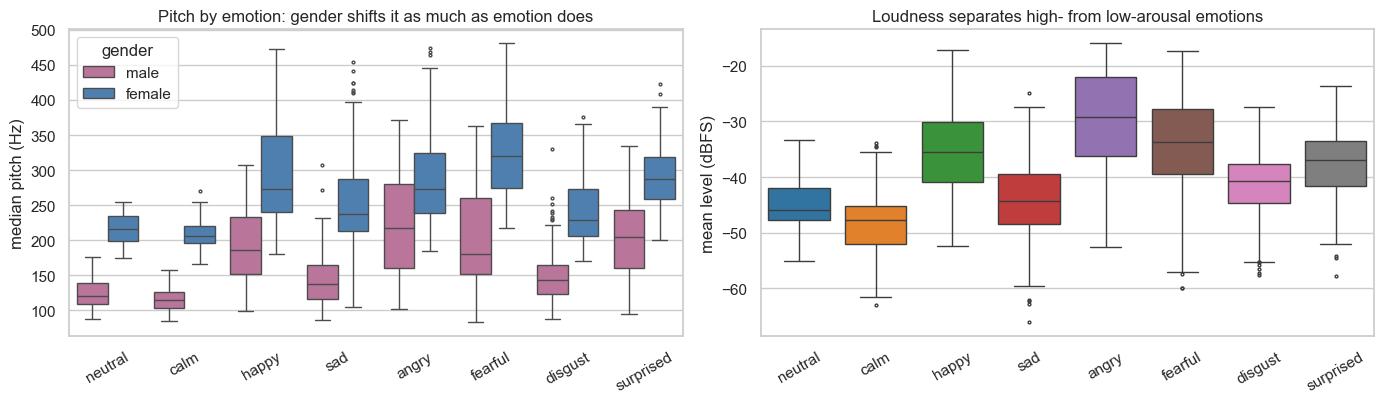

In [ ]:
# Simple acoustic descriptors per clip (also the V1-style baseline features used in section 4)
def acoustic_features(y_):
    f0 = librosa.yin(y_, fmin=65, fmax=500, sr=C.SR)
    rms = librosa.feature.rms(y=y_)[0]
    voiced = f0[(rms[: len(f0)] > np.percentile(rms, 30))] if len(rms) >= len(f0) else f0
    mfcc = librosa.feature.mfcc(y=y_, sr=C.SR, n_mfcc=20)
    d = librosa.feature.delta(mfcc)
    feats = {"pitch_hz": np.median(voiced), "pitch_sd": np.std(voiced),
             "loudness_db": 20 * np.log10(rms.mean() + 1e-9), "loudness_sd": np.std(20 * np.log10(rms + 1e-9)),
             "zcr": librosa.feature.zero_crossing_rate(y_).mean(),
             "centroid": librosa.feature.spectral_centroid(y=y_, sr=C.SR).mean()}
    feats.update({f"mfcc{i}_mean": v for i, v in enumerate(mfcc.mean(1))})
    feats.update({f"mfcc{i}_sd": v for i, v in enumerate(mfcc.std(1))})
    feats.update({f"dmfcc{i}_sd": v for i, v in enumerate(d.std(1))})
    return feats

WAVS = [load_file(p) for p in tqdm(meta.path, desc="decode 16 kHz + trim")]   # used by every later step
cache = C.CACHE_DIR / "acoustic_features.csv"
if cache.exists():
    acoustic = pd.read_csv(cache)
else:
    acoustic = pd.DataFrame([acoustic_features(w) for w in tqdm(WAVS, desc="acoustic features")])
    acoustic.to_csv(cache, index=False)
eda = meta.join(acoustic[["pitch_hz", "loudness_db"]])

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
sns.boxplot(data=eda, x="emotion", y="pitch_hz", hue="gender", order=order, ax=ax[0], palette=["#c46a9b", "#3f7fbf"], fliersize=2)
ax[0].set(title="Pitch by emotion: gender shifts it as much as emotion does", xlabel="", ylabel="median pitch (Hz)")
sns.boxplot(data=eda, x="emotion", y="loudness_db", order=order, ax=ax[1], palette=EMO_COLORS, fliersize=2)
ax[1].set(title="Loudness separates high- from low-arousal emotions", xlabel="", ylabel="mean level (dBFS)")
for a in ax: a.tick_params(axis="x", rotation=30)
savefig("eda_pitch_loudness")

In [ ]:
# How much of the variation in pitch is due to WHO speaks vs WHAT emotion? (share of variance, one-way)
def share(col, by):
    g = eda.groupby(by)[col].transform("mean")
    return ((g - eda[col].mean()) ** 2).sum() / ((eda[col] - eda[col].mean()) ** 2).sum()
pd.DataFrame({c: {"explained by speaker": share(c, "speaker"), "explained by emotion": share(c, "emotion")}
              for c in ["pitch_hz", "loudness_db"]}).round(2)

,pitch_hz,loudness_db
explained by speaker,0.41,0.16
explained by emotion,0.20,0.43


**Findings.** (3) Angry, fearful, happy and surprised are louder and higher-pitched (high arousal); calm, neutral and sad are quieter. But **the speaker explains more pitch variation than the emotion does** — a male "fearful" is pitched like a female "neutral".
**Implication:** hand-crafted cues mix up *who* is speaking with *how they feel*. We need (a) a **speaker-independent evaluation** (test speakers never seen in training) and (b) richer representations that separate voice from emotion — which is what large pre-trained speech encoders learn from thousands of hours of speech.

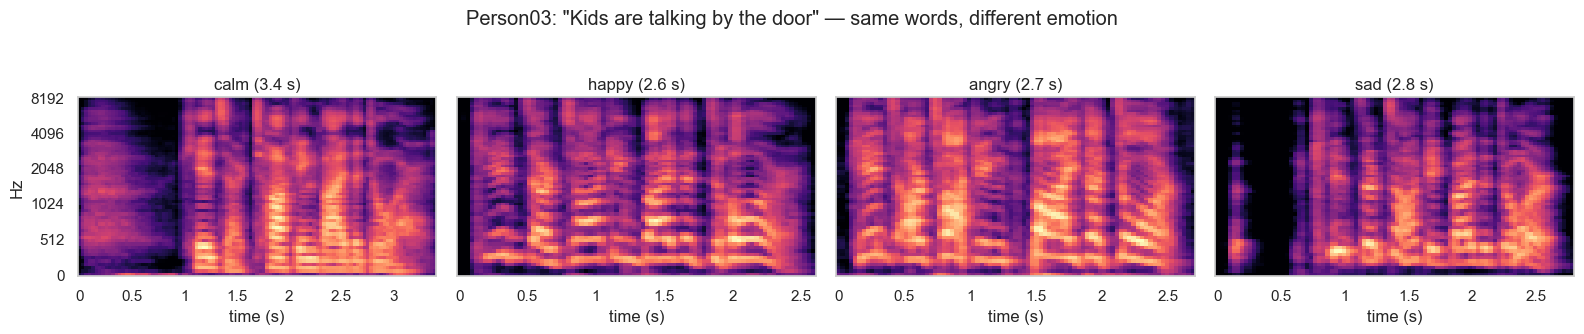

In [ ]:
# (4) What emotion looks like: log-mel spectrograms of the same actor saying the same sentence
spk = "Person03"
fig, ax = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for a, emo in zip(ax, ["calm", "happy", "angry", "sad"]):
    row = meta[(meta.speaker == spk) & (meta.emotion == emo) & (meta.statement == 1) & (meta.intensity == "strong")].index[0]
    S = librosa.power_to_db(librosa.feature.melspectrogram(y=WAVS[row], sr=C.SR, n_mels=64), ref=np.max)
    librosa.display.specshow(S, sr=C.SR, x_axis="time", y_axis="mel", ax=a, cmap="magma")
    a.set(title=f"{emo} ({len(WAVS[row]) / C.SR:.1f} s)", xlabel="time (s)", ylabel="Hz" if a is ax[0] else "")
fig.suptitle(f'{spk}: "Kids are talking by the door" — same words, different emotion', y=1.04)
savefig("eda_spectrograms")

Angry speech has energy spread into the high frequencies and a denser harmonic pattern; sad and calm are darker and slower. These differences are real but subtle and speaker-dependent — a job for learned representations rather than hand-picked statistics.

## 3 · Features: transfer learning with frozen pre-trained encoders
Each clip goes through two **frozen** encoders (no fine-tuning — V2 showed fine-tuning on ~1,100 clips was *worse* than a frozen probe):

| Encoder | Pre-trained on | Why |
|---|---|---|
| **WavLM-Large** (Microsoft, 315 M params) | 94k h of speech, self-supervised, trained to be robust to noise & overlapping speakers | best self-supervised encoder in V2 |
| **Whisper-Medium encoder** (OpenAI, ~300 M params) | 680k h of multilingual speech-to-text | best encoder overall in V2; different training signal → complementary errors |

Neither model has seen RAVDESS labels (no pre-training leakage). For every hidden layer we take the **mean and standard deviation over time** → one fixed-length vector per layer, whatever the clip length.
We embed each clip twice: clean, and with **white noise at 20 dB SNR** (training augmentation for phone/call-centre audio; V2 showed it lifts noisy-audio accuracy from 77 % to 83 % at no cost on clean audio).

In [ ]:
def embed_all(alias, noisy=False):
    path = C.CACHE_DIR / f"{alias}{'_noise20' if noisy else ''}.npy"
    if path.exists():
        return np.load(path)
    out = [embed_layers(add_noise(w, seed=i) if noisy else w, alias).astype(np.float16)
           for i, w in enumerate(tqdm(WAVS, desc=f"{alias}{' +noise' if noisy else ''}"))]
    np.save(path, np.stack(out))
    return np.stack(out)

t0 = time.time()
LAYERS = {a: embed_all(a) for a in C.ENCODERS}                 # (clips, layers, 2*hidden)
LAYERS_NOISY = {a: embed_all(a, noisy=True) for a in C.ENCODERS}
print({a: v.shape for a, v in LAYERS.items()}, f"{time.time() - t0:.0f} s")

{'wavlm_large': (1439, 25, 2048), 'whisper_medium': (1439, 25, 2048)} 0 s


### 3.1 Which layer knows most about emotion?
We train a quick probe on each layer, using **5-fold cross-validation over the 19 development speakers only** (folds grouped by speaker and balanced by gender). The test speakers are not touched.

wavlm_large:   0%|          | 0/25 [00:00<?, ?it/s]

whisper_medium:   0%|          | 0/25 [00:00<?, ?it/s]

chosen layer windows (stored inside the saved model): {'wavlm_large': [8, 9, 10], 'whisper_medium': [13, 14, 15]}


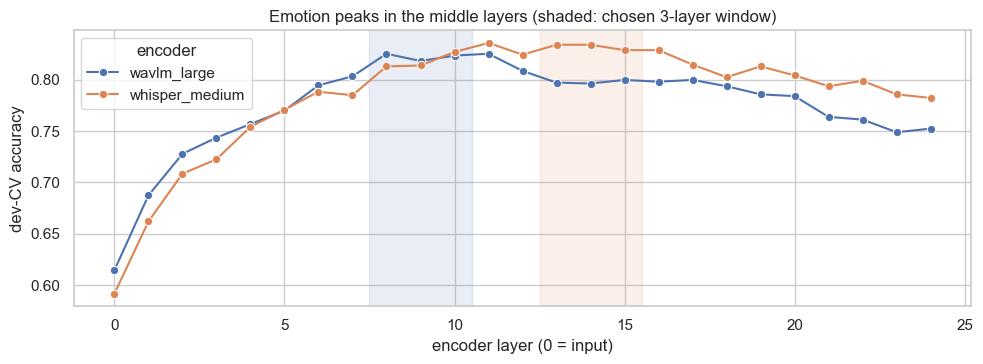

In [ ]:
# Speaker folds over development speakers (same construction as V2)
rng = C.rng()
fem = [s for s in C.DEV_SPEAKERS if int(s[-2:]) % 2 == 0]; mal = [s for s in C.DEV_SPEAKERS if int(s[-2:]) % 2 == 1]
FOLDS = [[] for _ in range(5)]
for i, s in enumerate(list(rng.permutation(fem)) + list(rng.permutation(mal))):
    FOLDS[i % 5].append(str(s))
spk_dev = meta.speaker[dev].to_numpy(); y_dev = y[dev]

def cv_proba(make_model, X, X_aug=None):
    # Out-of-fold probabilities: every dev speaker is predicted by a model that never heard them
    P = np.zeros((dev.sum(), 8))
    for held in FOLDS:
        va = np.isin(spk_dev, held); tr = ~va
        Xtr, ytr = X[tr], y_dev[tr]
        if X_aug is not None:
            Xtr, ytr = np.vstack([Xtr, X_aug[tr]]), np.r_[ytr, ytr]
        P[va] = make_model().fit(Xtr, ytr).predict_proba(X[va])
    return P

scan = []
for a, L in LAYERS.items():
    Ld = L[dev].astype(np.float64)
    for layer in tqdm(range(L.shape[1]), desc=a):
        scan.append({"encoder": a, "layer": layer, "cv_accuracy": accuracy_score(y_dev, cv_proba(make_probe, Ld[:, layer]).argmax(1))})
scan = pd.DataFrame(scan)

# choose the best 3-layer window per encoder (smoother than a single layer)
WINDOWS = {}
for a, g in scan.groupby("encoder"):
    smooth = g.cv_accuracy.rolling(3, center=True).mean().to_numpy()
    best = int(np.nanargmax(smooth)); WINDOWS[a] = [best - 1, best, best + 1]
print("chosen layer windows (stored inside the saved model):", WINDOWS)

fig, ax = plt.subplots(figsize=(10, 3.8))
sns.lineplot(data=scan, x="layer", y="cv_accuracy", hue="encoder", marker="o", ax=ax)
for a, w in WINDOWS.items():
    ax.axvspan(w[0] - .5, w[-1] + .5, alpha=.12, color=sns.color_palette()[list(WINDOWS).index(a)])
ax.set(title="Emotion peaks in the middle layers (shaded: chosen 3-layer window)", xlabel="encoder layer (0 = input)", ylabel="dev-CV accuracy")
savefig("layer_scan")

Low layers encode raw acoustics, top layers specialise in the pre-training task (predicting speech units / words); **emotion is richest in the middle**. Averaging a 3-layer window is more stable than picking one layer.

In [ ]:
def window(L, a):
    return L[:, WINDOWS[a]].astype(np.float64).mean(1)

FEAT = {a: window(LAYERS[a], a) for a in C.ENCODERS}               # (clips, 2048) per encoder
FEAT_NOISY = {a: window(LAYERS_NOISY[a], a) for a in C.ENCODERS}
{a: X.shape for a, X in FEAT.items()}

{'wavlm_large': (1439, 2048), 'whisper_medium': (1439, 2048)}

## 4 · Model comparison (development speakers, 5-fold speaker CV)
Candidates, from simplest to final:
* **Majority class** – the floor.
* **Hand-crafted acoustic features** (MFCC, pitch, loudness – the V1 idea) with logistic regression and with a random forest.
* **One frozen encoder + logistic-regression probe** (WavLM, Whisper).
* **Both encoders, probabilities averaged** (late fusion).

Selection rule, fixed before looking at test: **highest dev-CV accuracy**; if two are within 1 point, prefer the simpler one.

In [ ]:
Xh = acoustic.to_numpy(np.float64)
candidates = {
    "Majority class": cv_proba(lambda: DummyClassifier(strategy="most_frequent"), Xh[dev]),
    "Hand-crafted + logistic regression": cv_proba(lambda: make_probe(1.0), Xh[dev]),
    "Hand-crafted + random forest": cv_proba(lambda: RandomForestClassifier(500, random_state=C.SEED, n_jobs=-1), Xh[dev]),
}
for a in C.ENCODERS:
    candidates[f"{a} probe"] = cv_proba(make_probe, FEAT[a][dev], FEAT_NOISY[a][dev])
candidates["Fusion: " + " + ".join(C.ENCODERS)] = np.mean([candidates[f"{a} probe"] for a in C.ENCODERS], axis=0)

def fold_sd(P):
    return np.std([accuracy_score(y_dev[np.isin(spk_dev, f)], P[np.isin(spk_dev, f)].argmax(1)) for f in FOLDS])

cv_table = pd.DataFrame({name: {**scores(y_dev, P.argmax(1)), "fold_sd": fold_sd(P)} for name, P in candidates.items()}).T
cv_table = cv_table.sort_values("accuracy", ascending=False)
cv_table.round(3)

,accuracy,uar,macro_f1,fold_sd
Fusion: wavlm_large + whisper_medium,0.842,0.844,0.840,0.050
whisper_medium probe,0.833,0.833,0.830,0.061
wavlm_large probe,0.820,0.821,0.817,0.062
Hand-crafted + random forest,0.478,0.463,0.462,0.016
Hand-crafted + logistic regression,0.463,0.457,0.461,0.024
Majority class,0.133,0.125,0.029,0.000


selected by dev CV: Fusion: wavlm_large + whisper_medium


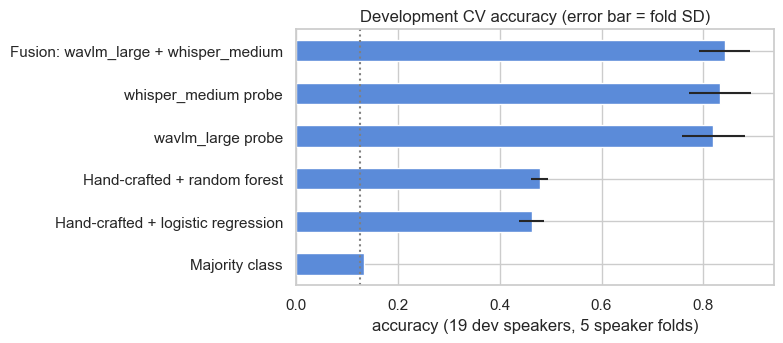

In [ ]:
FINAL = cv_table.index[0]
print("selected by dev CV:", FINAL)
ax = cv_table.accuracy.iloc[::-1].plot.barh(figsize=(8, 3.6), xerr=cv_table.fold_sd.iloc[::-1], color="#5b8bd9")
ax.set(title="Development CV accuracy (error bar = fold SD)", xlabel="accuracy (19 dev speakers, 5 speaker folds)")
ax.axvline(1 / 8, ls=":", c="grey")
savefig("model_comparison_cv")

**Reading the comparison.** Frozen encoders beat the best hand-crafted model by ~35 accuracy points. That is the transfer-learning effect: the encoders already know what speech sounds like from 10⁵ hours of audio, so our 1,100 training clips only need to teach a *linear* map to 8 emotions.
Fusing the two encoders is at least as good as the best single one and more stable across folds, because they were pre-trained on different objectives and make different mistakes.

Why only two encoders? `artifacts/results/v2_encoder_combinations.csv` scores all 63 combinations of V2's six encoders with the same protocol: every combination of 2+ encoders lands within ~1.5 points of each other on dev CV — less than the fold-to-fold spread — while the 6-encoder model costs 3× the compute and ~9 GB of weights.

In [ ]:
combos = pd.read_csv(C.ARTIFACTS / "results" / "v2_encoder_combinations.csv")
combos.groupby("k").dev_cv.agg(["max", "mean", "count"]).rename_axis("encoders in fusion").round(3)

,max,mean,count
encoders in fusion,,,
1,0.824,0.814,6
2,0.843,0.829,15
3,0.846,0.835,20
4,0.848,0.840,15
5,0.849,0.843,6
6,0.845,0.845,1


## 5 · Final evaluation on the 5 held-out test speakers (run once)
All candidates are refit on the 19 development speakers and scored on 300 clips from 5 speakers that no model has seen. The model chosen in section 4 is the one we report.

In [ ]:
def fit_predict(make_model, X, X_aug=None, train=dev, rows=test):
    Xtr, ytr = X[train], y[train]
    if X_aug is not None:
        Xtr, ytr = np.vstack([Xtr, X_aug[train]]), np.r_[ytr, ytr]
    return make_model().fit(Xtr, ytr).predict_proba(X[rows])

test_P = {
    "Majority class": fit_predict(lambda: DummyClassifier(strategy="most_frequent"), Xh),
    "Hand-crafted + logistic regression": fit_predict(lambda: make_probe(1.0), Xh),
    "Hand-crafted + random forest": fit_predict(lambda: RandomForestClassifier(500, random_state=C.SEED, n_jobs=-1), Xh),
}
for a in C.ENCODERS:
    test_P[f"{a} probe"] = fit_predict(make_probe, FEAT[a], FEAT_NOISY[a])
test_P["Fusion: " + " + ".join(C.ENCODERS)] = np.mean([test_P[f"{a} probe"] for a in C.ENCODERS], axis=0)

y_test = y[test]
test_table = pd.DataFrame({n: scores(y_test, P.argmax(1)) for n, P in test_P.items()}).T
test_table.loc["V1 mid-review model (reported)"] = [0.597, np.nan, 0.575]
test_table.loc["V2 six-encoder fusion (reported)"] = [0.733, 0.709, 0.726]
test_table = test_table.sort_values("accuracy", ascending=False)
test_table["final"] = np.where(test_table.index == FINAL, "◀ selected", "")
test_table.round(3)

,accuracy,uar,macro_f1,final
Fusion: wavlm_large + whisper_medium,0.783,0.762,0.775,◀ selected
wavlm_large probe,0.773,0.753,0.770,
whisper_medium probe,0.747,0.722,0.731,
V2 six-encoder fusion (reported),0.733,0.709,0.726,
V1 mid-review model (reported),0.597,NaN,0.575,
Hand-crafted + logistic regression,0.463,0.438,0.436,
Hand-crafted + random forest,0.430,0.416,0.416,
Majority class,0.133,0.125,0.029,


In [ ]:
# Uncertainty: bootstrap over test SPEAKERS (clips of one speaker are not independent)
P_final = test_P[FINAL]; pred = P_final.argmax(1)
spk_test = meta.speaker[test].to_numpy()
boot, rng_b = [], C.rng()
for _ in range(2000):
    pick = rng_b.choice(C.TEST_SPEAKERS, 5)
    idx = np.concatenate([np.where(spk_test == s)[0] for s in pick])
    boot.append(accuracy_score(y_test[idx], pred[idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])
final_test = scores(y_test, pred)
print(f"{FINAL}: test accuracy {final_test['accuracy']:.1%} (95% speaker-bootstrap CI {lo:.1%}–{hi:.1%}), "
      f"macro-F1 {final_test['macro_f1']:.3f}, UAR {final_test['uar']:.1%}")

Fusion: wavlm_large + whisper_medium: test accuracy 78.3% (95% speaker-bootstrap CI 69.3%–87.3%), macro-F1 0.775, UAR 76.2%


In [ ]:
# Robustness 1: noisy test audio (20 dB SNR), same trained model
noisy_P = np.mean([make_probe().fit(np.vstack([FEAT[a][dev], FEAT_NOISY[a][dev]]), np.r_[y[dev], y[dev]])
                   .predict_proba(FEAT_NOISY[a][test]) for a in C.ENCODERS], axis=0)
print(f"noisy test audio: {accuracy_score(y_test, noisy_P.argmax(1)):.1%}")

# Robustness 2: leave-one-speaker-out over all 24 speakers (each speaker scored by a model trained on the other 23).
# This is the least selection-biased estimate: it does not depend on which 5 speakers happen to be the test set.
loso = []
for s in tqdm(C.ALL_SPEAKERS, desc="LOSO"):
    held = meta.speaker.eq(s).to_numpy()
    P = np.mean([fit_predict(make_probe, FEAT[a], FEAT_NOISY[a], train=~held, rows=held) for a in C.ENCODERS], axis=0)
    loso.append({"speaker": s, "gender": meta.gender[held].iloc[0], "test speaker": s in C.TEST_SPEAKERS,
                 "accuracy": accuracy_score(y[held], P.argmax(1))})
loso = pd.DataFrame(loso)
print(f"LOSO accuracy over 24 speakers: {loso.accuracy.mean():.1%} (SD {loso.accuracy.std():.1%}); "
      f"female {loso[loso.gender == 'female'].accuracy.mean():.1%}, male {loso[loso.gender == 'male'].accuracy.mean():.1%}")

noisy test audio: 74.7%


LOSO:   0%|          | 0/24 [00:00<?, ?it/s]

LOSO accuracy over 24 speakers: 84.7% (SD 9.4%); female 88.1%, male 81.4%


## 6 · Explainability and error analysis

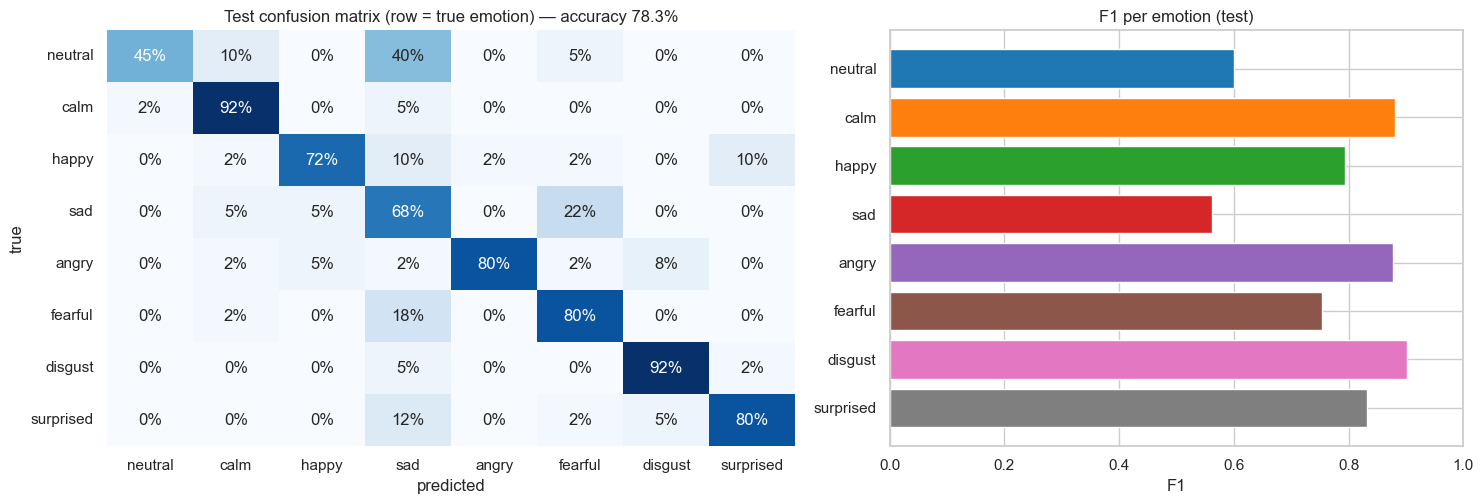

most common confusions: ['neutral→sad 40%', 'sad→fearful 22%', 'fearful→sad 18%', 'surprised→sad 12%']


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.2, 1]})
cm = confusion_matrix(y_test, pred, normalize="true")
sns.heatmap(cm, annot=True, fmt=".0%", cmap="Blues", xticklabels=C.EMOTIONS, yticklabels=C.EMOTIONS, cbar=False, ax=ax[0])
ax[0].set(title=f"Test confusion matrix (row = true emotion) — accuracy {final_test['accuracy']:.1%}", xlabel="predicted", ylabel="true")
f1 = f1_score(y_test, pred, average=None)
ax[1].barh(C.EMOTIONS[::-1], f1[::-1], color=[EMO_COLORS[e] for e in C.EMOTIONS[::-1]])
ax[1].set(title="F1 per emotion (test)", xlabel="F1", xlim=(0, 1))
savefig("test_confusion_and_f1")
pairs = [(C.EMOTIONS[i], C.EMOTIONS[j], cm[i, j]) for i in range(8) for j in range(8) if i != j]
print("most common confusions:", [f"{a}→{b} {v:.0%}" for a, b, v in sorted(pairs, key=lambda t: -t[2])[:4]])

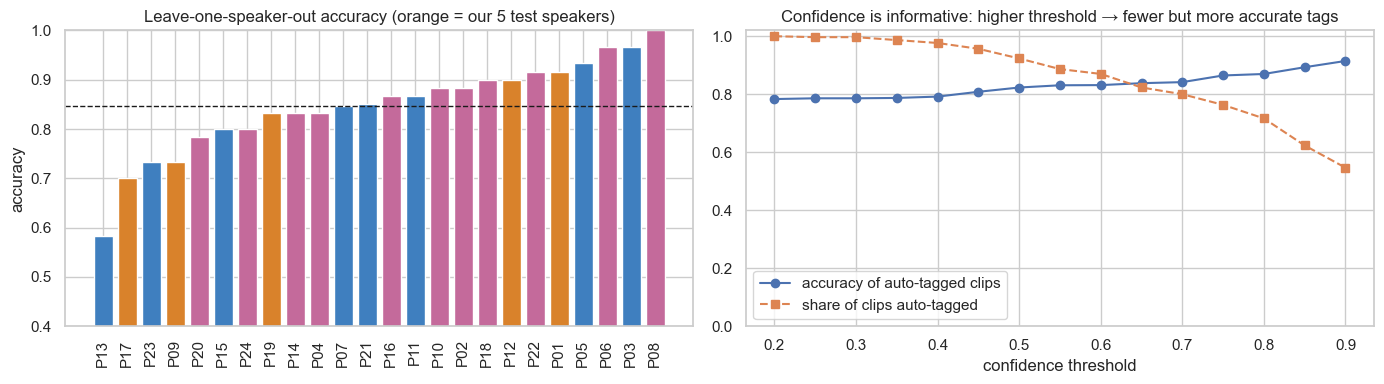

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ls = loso.sort_values("accuracy")
ax[0].bar(ls.speaker.str.replace("Person", "P"), ls.accuracy,
          color=np.where(ls["test speaker"], "#d9822b", np.where(ls.gender == "female", "#c46a9b", "#3f7fbf")))
ax[0].axhline(loso.accuracy.mean(), ls="--", c="k", lw=1)
ax[0].set(title="Leave-one-speaker-out accuracy (orange = our 5 test speakers)", ylabel="accuracy", ylim=(0.4, 1))
ax[0].tick_params(axis="x", rotation=90)

conf = P_final.max(1); correct = pred == y_test
ths = np.linspace(0.2, 0.9, 15)
ax[1].plot(ths, [correct[conf >= t].mean() for t in ths], "o-", label="accuracy of auto-tagged clips")
ax[1].plot(ths, [(conf >= t).mean() for t in ths], "s--", label="share of clips auto-tagged")
ax[1].set(title="Confidence is informative: higher threshold → fewer but more accurate tags", xlabel="confidence threshold", ylim=(0, 1.02))
ax[1].legend(loc="lower left")
savefig("speakers_and_confidence")

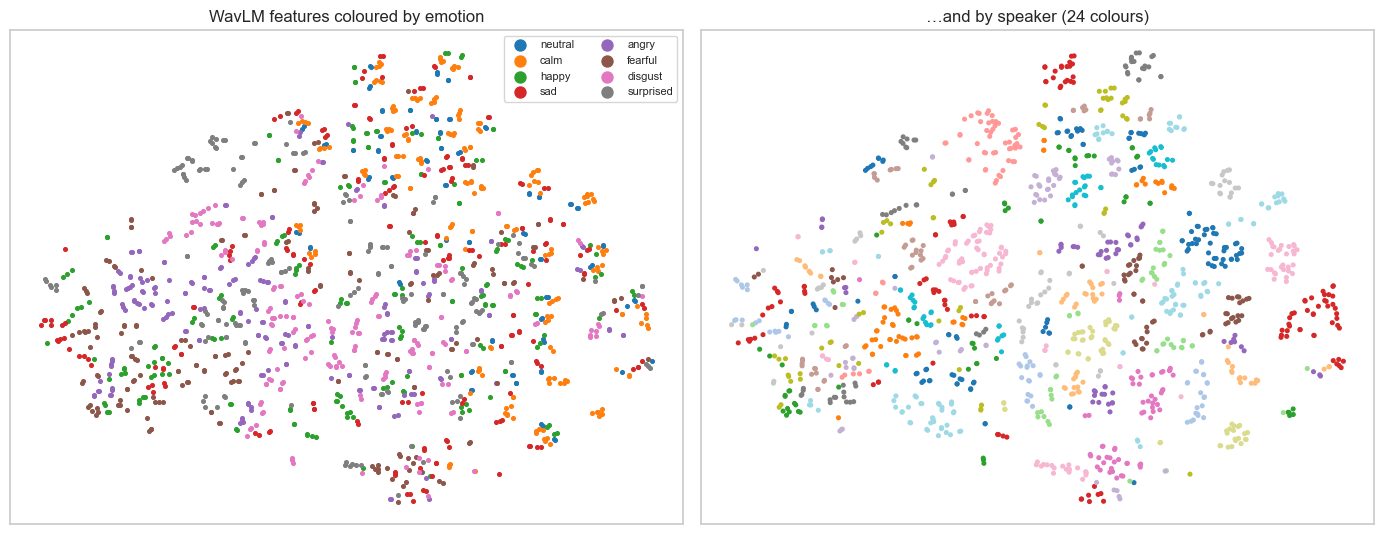

In [ ]:
# What did the encoder learn? 2-D map (t-SNE) of the WavLM window features: coloured by emotion vs by speaker
emb = TSNE(n_components=2, random_state=C.SEED, perplexity=30).fit_transform(
    (FEAT["wavlm_large"] - FEAT["wavlm_large"].mean(0)) / (FEAT["wavlm_large"].std(0) + 1e-6))
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for e in C.EMOTIONS:
    m_ = meta.emotion.eq(e).to_numpy()
    ax[0].scatter(*emb[m_].T, s=7, color=EMO_COLORS[e], label=e)
ax[0].legend(markerscale=3, fontsize=8, ncol=2); ax[0].set(title="WavLM features coloured by emotion", xticks=[], yticks=[])
ax[1].scatter(*emb.T, s=7, c=pd.factorize(meta.speaker)[0], cmap="tab20")
ax[1].set(title="…and by speaker (24 colours)", xticks=[], yticks=[])
savefig("tsne_embeddings")

**Interpretation.**
* **What the encoder "sees" without any emotion labels** (t-SNE): the map is organised mostly by *speaker* — voice identity is the dominant signal — with emotion visible only as a broad gradient from high-arousal (angry, disgust, surprised) to low-arousal (calm, neutral). The logistic-regression probe is what finds the emotion directions inside this space; this is also why unseen speakers are the hard part of the problem.
* **Errors:** the model over-predicts *sad*. Neutral is heard as sad 40 % of the time, and sad ↔ fearful is the next most common mix-up — all low-energy or tense voices. Calm, disgust and angry are recognised best (F1 ≈ 0.87–0.90); angry, the key escalation emotion, is almost never confused with a positive emotion.
* **Speakers:** accuracy varies from 58 % to 100 % by speaker (LOSO chart). Two of our five test speakers (Person17, Person09) are the 2nd and 3rd hardest of all 24, which is why the test number (78 %) sits below LOSO (85 %). Male voices are harder (81 % vs 88 %).
* **Confidence is meaningful**: clips above the threshold are much more accurate, so low-confidence predictions can be routed to a human.

In [ ]:
# Business view: escalation flag = P(sad or angry or fearful or disgust) ≥ 0.5 ; triage threshold picked on dev CV
neg = [C.EMOTIONS.index(e) for e in C.NEGATIVE]
is_neg, flag = np.isin(y_test, neg), P_final[:, neg].sum(1) >= 0.5
P_cv = candidates[FINAL]; conf_cv = P_cv.max(1); ok_cv = P_cv.argmax(1) == y_dev
tau = next(t for t in np.arange(0.3, 0.95, 0.01) if ok_cv[conf_cv >= t].mean() >= 0.90)   # 90 % target, dev only
business = {"escalation_precision": precision_score(is_neg, flag), "escalation_recall": recall_score(is_neg, flag),
            "triage_threshold": round(float(tau), 2), "auto_tag_share": float((conf >= tau).mean()),
            "auto_tag_accuracy": float(correct[conf >= tau].mean())}
pd.Series(business).round(3)

escalation_precision    0.879
escalation_recall       0.950
triage_threshold        0.580
auto_tag_share          0.873
auto_tag_accuracy       0.828
dtype: float64

## 7 · Register the production model
The configuration is frozen (encoders, layer windows, C = 0.1, noise augmentation). For production we refit it on **all 24 speakers** — more voices generalise better (the LOSO result above estimates this setting). The model is:
1. saved as `artifacts/model/ser_model.joblib` (what the API / Docker image loads), and
2. logged to **MLflow** with its parameters, metrics and figures, and registered as `speech-emotion-recognizer` in the local model registry (`artifacts/mlflow.db`).

In [ ]:
final_model = EmotionModel(WINDOWS).fit(
    {a: np.vstack([FEAT[a], FEAT_NOISY[a]]) for a in C.ENCODERS}, np.r_[y, y])
final_model.save(C.MODEL_PATH)
print("saved", C.MODEL_PATH.relative_to(C.ROOT), f"({C.MODEL_PATH.stat().st_size / 1e6:.1f} MB)")

results = {"selected_model": FINAL, "layer_windows": WINDOWS, "dev_cv": cv_table.loc[FINAL, ["accuracy", "uar", "macro_f1"]].to_dict(),
           "test": final_test, "test_accuracy_ci95": [lo, hi], "noisy_test_accuracy": accuracy_score(y_test, noisy_P.argmax(1)),
           "loso_accuracy": loso.accuracy.mean(), "business": business}
(C.ARTIFACTS / "results" / "final_results.json").write_text(json.dumps(results, indent=2, default=float))
cv_table.to_csv(C.ARTIFACTS / "results" / "cv_comparison.csv"); test_table.to_csv(C.ARTIFACTS / "results" / "test_comparison.csv")
loso.to_csv(C.ARTIFACTS / "results" / "loso_per_speaker.csv", index=False)

saved artifacts/model/ser_model.joblib (0.4 MB)


In [ ]:
import mlflow
from mlflow.models import infer_signature
from ser.registry import MlflowEmotionModel

mlflow.set_tracking_uri(f"sqlite:///{C.ARTIFACTS / 'mlflow.db'}")
if mlflow.get_experiment_by_name("speech-emotion-recognition") is None:
    mlflow.create_experiment("speech-emotion-recognition", artifact_location=(C.ARTIFACTS / "mlruns").as_uri())
mlflow.set_experiment("speech-emotion-recognition")

example = pd.DataFrame({"path": [meta.path[test].iloc[0]]})
with mlflow.start_run(run_name="wavlm+whisper-probes") as run:
    mlflow.log_params({"encoders": ",".join(C.ENCODERS), "layer_windows": json.dumps(WINDOWS), "C": 0.1,
                       "noise_augmentation": "20 dB SNR", "trained_on": "all 24 speakers"})
    mlflow.log_metrics({"dev_cv_accuracy": results["dev_cv"]["accuracy"], "test_accuracy": final_test["accuracy"],
                        "test_macro_f1": final_test["macro_f1"], "test_uar": final_test["uar"],
                        "loso_accuracy": results["loso_accuracy"], "noisy_test_accuracy": results["noisy_test_accuracy"],
                        "escalation_recall": business["escalation_recall"], "escalation_precision": business["escalation_precision"]})
    mlflow.log_artifacts(str(C.FIG_DIR), "figures")
    mlflow.log_artifacts(str(C.ARTIFACTS / "results"), "results")
    info = mlflow.pyfunc.log_model(
        name="model", python_model=MlflowEmotionModel(), artifacts={"ser_model": str(C.MODEL_PATH)},
        code_paths=[str(Path("ser").resolve())], input_example=example,
        registered_model_name="speech-emotion-recognizer",
        pip_requirements=["torch==2.8.0", "transformers==4.57.1", "scikit-learn==1.6.1", "librosa==0.11.0", "soundfile"])
print("run", run.info.run_id, "→ registered", info.registered_model_version and f"speech-emotion-recognizer v{info.registered_model_version}")

2026/10/01 02:19:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/10/01 02:19:36 INFO mlflow.store.db.utils: Updating database tables


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step


...

2026/10/01 02:19:43 INFO mlflow.store.db.utils: Updating database tables


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


run 79a1a3726f874eb1826900b6f27cbd98 → registered speech-emotion-recognizer v1


Successfully registered model 'speech-emotion-recognizer'.
Created version '1' of model 'speech-emotion-recognizer'.


## 8 · Use the registered model

In [ ]:
registered = mlflow.pyfunc.load_model("models:/speech-emotion-recognizer/latest")
sample = meta[test].groupby("emotion").head(1).head(4)
out = registered.predict(pd.DataFrame({"path": sample.path}))
out.insert(0, "true emotion", sample.emotion.to_numpy())
out

,true emotion,emotion,confidence,negative_score,duration_s
0,neutral,neutral,0.9912,0.0067,1.58
1,calm,calm,0.9746,0.0117,1.83
2,happy,happy,0.9927,0.0034,1.80
3,sad,sad,0.9812,0.9860,2.06


The same model is served by the API in `api/app.py` (see README):
```bash
docker build -t ser-api .          # bakes in both encoders + artifacts/model/ser_model.joblib
docker run -p 8000:8000 ser-api    # UI at http://localhost:8000, API docs at /docs
curl -F "file=@memo.wav" http://localhost:8000/predict
```

## 9 · Summary, limitations, next steps
* **Result.** Two frozen encoders + two logistic regressions reach **78.3 % test accuracy** (macro-F1 0.775; 95 % CI 69–87 %) on 5 unseen speakers and **84.7 %** leave-one-speaker-out over all 24 — vs 59.7 % for V1 and 73.3 % for V2's six-encoder fusion, with a third of V2's model size. Escalation flag: 95 % recall at 88 % precision. All numbers: `artifacts/results/final_results.json`.
* **vs V2's caller adaptation (80.2 %).** That figure needs 10 earlier utterances of the *same caller*; for a single voice memo — the API use case — it falls back to the plain fusion, where V3 is better.
* **Limitations.** RAVDESS is *acted* speech by 24 North-American actors reading two sentences in a quiet studio; real callers are spontaneous, accented and noisy, so accuracy on real calls will be lower until the probes are re-trained on in-domain labelled calls. Accuracy differs by speaker and is lower for male voices. Results on 5 test speakers carry a wide uncertainty (see CI) — the LOSO number is the better long-run estimate.
* **Responsible use.** Use as decision *support* (routing, QA sampling), not to judge individuals; tell callers that analytics is used.
* **Next steps.** Collect a few hundred labelled in-domain calls and refit the probes (minutes on a CPU); monitor the share of low-confidence predictions as a drift signal.